# Challenge: Quantum Randomness vs Classical Pseudo-Randomness

### Objective

Compare quantum measurement randomness with a biased classical pseudo-random
generator using measurement statistics and hypothesis testing.

### Theory

A Hadamard-based quantum measurement produces approximately equal probabilities
of 0 and 1.

A classical pseudo-random generator can be intentionally biased. A chi-square
test can be used to determine whether the observed results significantly differ
from an expected 50–50 distribution.

In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chisquare

simulator = AerSimulator()

In [2]:
shots = 1000

# Quantum random bits
qc5 = QuantumCircuit(1, 1)
qc5.h(0)
qc5.measure(0, 0)

quantum = simulator.run(qc5, shots=shots).result().get_counts()

# Biased classical random bits
classical = np.random.choice([0, 1], shots, p=[0.7, 0.3])

classical_counts = {
    '0': np.sum(classical == 0),
    '1': np.sum(classical == 1)
}

print("Quantum:", quantum)
print("Classical:", classical_counts)

Quantum: {'0': 486, '1': 514}
Classical: {'0': 700, '1': 300}


In [3]:
q = [quantum.get('0', 0), quantum.get('1', 0)]
c = [classical_counts['0'], classical_counts['1']]

q_test = chisquare(q, [500, 500])
c_test = chisquare(c, [500, 500])

print("Quantum p-value:", round(q_test.pvalue, 4))
print("Classical p-value:", round(c_test.pvalue, 4))

Quantum p-value: 0.3759
Classical p-value: 0.0


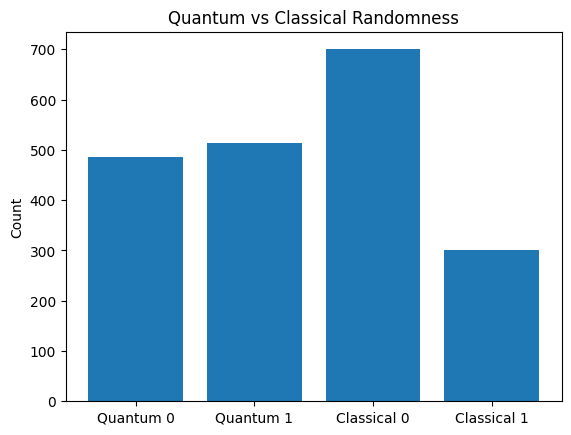

In [4]:
plt.bar(["Quantum 0", "Quantum 1", "Classical 0", "Classical 1"],
        q + c)

plt.ylabel("Count")
plt.title("Quantum vs Classical Randomness")
plt.show()

### Observation

The quantum experiment produced approximately equal numbers of 0 and 1,
consistent with a 50–50 distribution. The classical generator was intentionally
biased toward 0, producing a different distribution. The chi-square test
helps determine whether the observed difference from 50–50 is statistically
significant.